# Option 1 
Spring 2025 Project by Tarek Alhafez 100064737 for Data Science and AI 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Load the dataset
data = pd.read_csv("E:\\Codding work\\\DataForDataScienceAndAI\\Cars_data.csv")


<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
C:\Users\narut\AppData\Local\Temp\ipykernel_9560\1057297436.py:14: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("E:\\Codding work\\\DataForDataScienceAndAI\\Cars_data.csv")


# Data Exploration:



# Basic dataset info


In [2]:
#Getting Number of Columns(Features) and Enteries(Rows)
print("Dataset Shape:", data.shape)


Dataset Shape: (34033, 148)


In [3]:
#Getting an idea of how the data are enteried 
print("\nFirst 5 Rows:\n", data.head(15))



First 5 Rows:
     position                      loc  myear         bt         tt      ft  \
0         11                      NaN   2016        MUV     Manual  Diesel   
1         19         new delhi g.p.o.   2014        SUV     Manual  Diesel   
2         13                SECTOR 39   2020  Hatchback     Manual  Petrol   
3          9                 Dehradun   2018        SUV     Manual  Petrol   
4         12           kandivali west   2017        MUV     Manual  Diesel   
5         19                      NaN   2011        MUV     Manual  Diesel   
6         18                Pune City   2016  Hatchback     Manual  Petrol   
7         18           Bangalore City   2019  Hatchback  Automatic  Petrol   
8          6                      NaN   2018  Hatchback     Manual  Diesel   
9          9            borivali west   2013  Hatchback     Manual  Petrol   
10         1               hsr layout   2017  Hatchback     Manual  Petrol   
11         7                Pune City   2015    

In [4]:
#Getting data types to see if theres format problem and how should catagorical data be encoded or transformed 
print("\nData Types:\n", data.dtypes)



Data Types:
 position               int64
loc                   object
myear                  int64
bt                    object
tt                    object
                      ...   
Unnamed: 143         float64
Unnamed: 144         float64
Unnamed: 145         float64
Unnamed: 146         float64
Fuel Suppy System    float64
Length: 148, dtype: object


In [5]:
#Seeing number of missing values in each column, to see if it needs to be imputed or dropped, depending on the amount of missing values and if we need to column or not
#We can see that some clumn have few missing value, so we can impute them with KNNImputer, as its smarter than just filling with mean or median, as it reads the data and fills it with the most similar values
#We can also see that some columns have a lot of missing values, so we can drop them, as they are not useful for our model
print("\nMissing Values:\n", data.isnull().sum())



Missing Values:
 position                 0
loc                   5251
myear                    0
bt                      18
tt                       0
                     ...  
Unnamed: 143         34033
Unnamed: 144         34033
Unnamed: 145         34033
Unnamed: 146         34033
Fuel Suppy System    34033
Length: 148, dtype: int64


In [6]:

print("\nClass Distribution (tt):\n", data['tt'].value_counts())



Class Distribution (tt):
 tt
Manual       26034
Automatic     7999
Name: count, dtype: int64


For the cell above:
There seem to be an imbalance, we could use SMOTE to make the data more balanced in classification models, by generating synthetic samples for minority class to handle imbalanced datasets.

In [7]:

# Summary statistics for numerical columns
print("\nNumerical Columns Summary:\n", data.describe())


Numerical Columns Summary:
            position         myear            ip      imgCount       modelId  \
count  34033.000000  34033.000000  34033.000000  34033.000000  34033.000000   
mean      12.790115   2015.569565      0.010225     15.590662    813.503217   
std        4.538129      3.779233      0.100604      8.360744    907.644451   
min        1.000000   1983.000000      0.000000      0.000000      3.000000   
25%        9.000000   2013.000000      0.000000     10.000000    262.000000   
50%       13.000000   2016.000000      0.000000     15.000000    582.000000   
75%       17.000000   2018.000000      0.000000     21.000000    838.000000   
max       20.000000   2023.000000      1.000000     53.000000   3417.000000   

       centralVariantId  discountValue            msp        pageNo  \
count      34033.000000   34033.000000   34033.000000  34033.000000   
mean        4245.471013      68.815591      28.178533     76.342609   
std         2454.687987    2754.771227    5198

This function iterates over the columns and gives there, unique values(how many different values we have for the column), the total number of unique values, the % of null values, and type of data (Numirical or not )

In [8]:
# Enhanced loop to show unique values, their counts, null counts, null percentage, and categorize columns
numerical_cols = []
categorical_cols = []

for col in data.columns:
    unique_vals = data[col].unique()
    num_null = data[col].isnull().sum()
    pct_null = 100 * num_null / len(data)
    dtype = data[col].dtype

    print(f"Column: {col}")
    print(f"  Unique values: {unique_vals[:10]}{' ...' if len(unique_vals) > 10 else ''}")
    print(f"  Number of unique values: {len(unique_vals)}")
    print(f"  Value counts (top 5):")
    print(data[col].value_counts(dropna=False).head())
    print(f"  Null values: {num_null} ({pct_null:.2f}%)")
    print(f"  Dtype: {dtype}")

    if pd.api.types.is_numeric_dtype(data[col]):
        numerical_cols.append(col)
        print("  Category: Numerical")
    else:
        categorical_cols.append(col)
        print("  Category: Categorical")
    print("-" * 40)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")

Column: position
  Unique values: [11 19 13  9 12 18  6  1  7 10] ...
  Number of unique values: 20
  Value counts (top 5):
position
20    2255
11    2248
19    2243
10    2242
18    2241
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: int64
  Category: Numerical
----------------------------------------
Column: loc
  Unique values: [nan 'new delhi g.p.o.' 'SECTOR 39' 'Dehradun' 'kandivali west'
 'Pune City' 'Bangalore City' 'borivali west' 'hsr layout' 'gurgaon'] ...
  Number of unique values: 508
  Value counts (top 5):
loc
NaN                 5251
Pune City           1904
Gurgaon             1558
Bangalore City      1427
New Delhi G.P.O.    1281
Name: count, dtype: int64
  Null values: 5251 (15.43%)
  Dtype: object
  Category: Categorical
----------------------------------------
Column: myear
  Unique values: [2016 2014 2020 2018 2017 2011 2019 2013 2015 2012] ...
  Number of unique values: 34
  Value counts (top 5):
myear
2017    3534
2018    3310
2014    3171
2015    31

For the above loop, i saw a lot of null values columns like:  'template_name_new', 'page_template', 'template_Type_new', 'experiment', 'Unnamed: 132', 'Unnamed: 136', 'Unnamed: 137', 'Unnamed: 138', 'Unnamed: 139', 'Unnamed: 140', 'Unnamed: 141', 'Unnamed: 142', 'Unnamed: 143', 'Unnamed: 144', 'Unnamed: 145', 'Unnamed: 146', 'Fuel Suppy System

Moreover, for duplicate columns theres many, the car model year has a couple of columns, the transimission type has a couple of columns, the same for carType, engine_cc

There seem to be some wrong forms, like pu(which is price), where data are separated by commas
For top speed, accelaration, mileage, torque, and max power, there seem to be a format problem 

Theres many useless columns, like the columns which have links for the car picture, or page number, or id columns, or columns of the car color as they dont help in predicting the cars transmission 

In [9]:
# List of columns to drop
cols_to_drop = ["loc", "pi", "images", "dvn","model", "variantName" , "vlink", 'price', "msp","userCarId" , "usedCarSkuId", "ucid",
                "sid", "tmGaadiStore", "emiwidget", "leadForm", "leadFormCta", "compare", "brandingIcon", "top_features","comfort_features", "interior_features",
                "exterior_features", "safety_features", "Engine Type", "Value Configuration", "BoreX Stroke", "Front Brake Type", "Rear Brake Type", "model_type_new",
                "originalLocation", "page_title", "compare_car_details", "Seating Capacity" ,"model_year_new" , "car_type_new", "oem_name", "dealer_id_new"
                 , "fuel_type" , "variant_new",  "dynx_event", "dynx_pagetype", "variant_name", "model_year", "dealer_id", "owner_type", "body_type_new" ,
                  "Compression Ratio" , "Unnamed: 132" , "experiment", "template_Type_new", "page_template", "template_name_new", "page_type", "vehicle_type_new",
                  "car_segment" , "fuel_type_new", "model_name", "vid", "offers", "model_new" , "Compression Ratio", "engine_cc", "utype", "body_type_new",
                  "transmissionType","transmission_type","Ground Clearance Unladen", "city_y","city_name_new", "city_x","brand_new", "exterior_color",
                  "oem", "Color","ip", "pageType", "state", "dynx_totalvalue_x", "dynx_totalvalue_y", "state", "city_id_new ", "ip",
                   "Fuel Suppy System", "Unnamed: 146", "Unnamed: 145", "Unnamed: 144", "Unnamed: 143", "Unnamed: 142", "Unnamed: 141","Unnamed: 140", "Unnamed: 139", "Unnamed: 138", "Unnamed: 137", "Unnamed: 136"]   # Replace with your column names

for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(columns=[col])

Data Visualization:

In [10]:
import pandas as pd

# Assuming 'data' is your DataFrame
numerical_data = data.select_dtypes(include=['float64', 'int64', 'bool', 'int32', 'float32'])

# Display the resulting DataFrame with only numerical columns
print("Numerical Columns:\n", numerical_data.columns)
print("\nNumerical Data Preview:\n", numerical_data.head())

Numerical Columns:
 Index(['position', 'myear', 'imgCount', 'threesixty', 'modelId',
       'centralVariantId', 'discountValue', 'pageNo', 'views', 'usedCarId',
       'dynx_itemid_x', 'dynx_itemid2_x', 'corporateId', 'Displacement',
       'No of Cylinder', 'Values per Cylinder', 'No Door Numbers',
       'seating_capacity_new', 'model_id_new', 'city_id_new',
       'max_engine_capacity_new', 'km_driven', 'used_carid', 'dynx_itemid_y',
       'dynx_itemid2_y', 'min_engine_capacity_new'],
      dtype='object')

Numerical Data Preview:
    position  myear  imgCount  threesixty  modelId  centralVariantId  \
0        11   2016        10       False      368              2277   
1        19   2014        21       False      570              8182   
2        13   2020        15       False     3078              7251   
3         9   2018        21        True      245              6429   
4        12   2017        15       False      592              5635   

   discountValue  pageNo  views

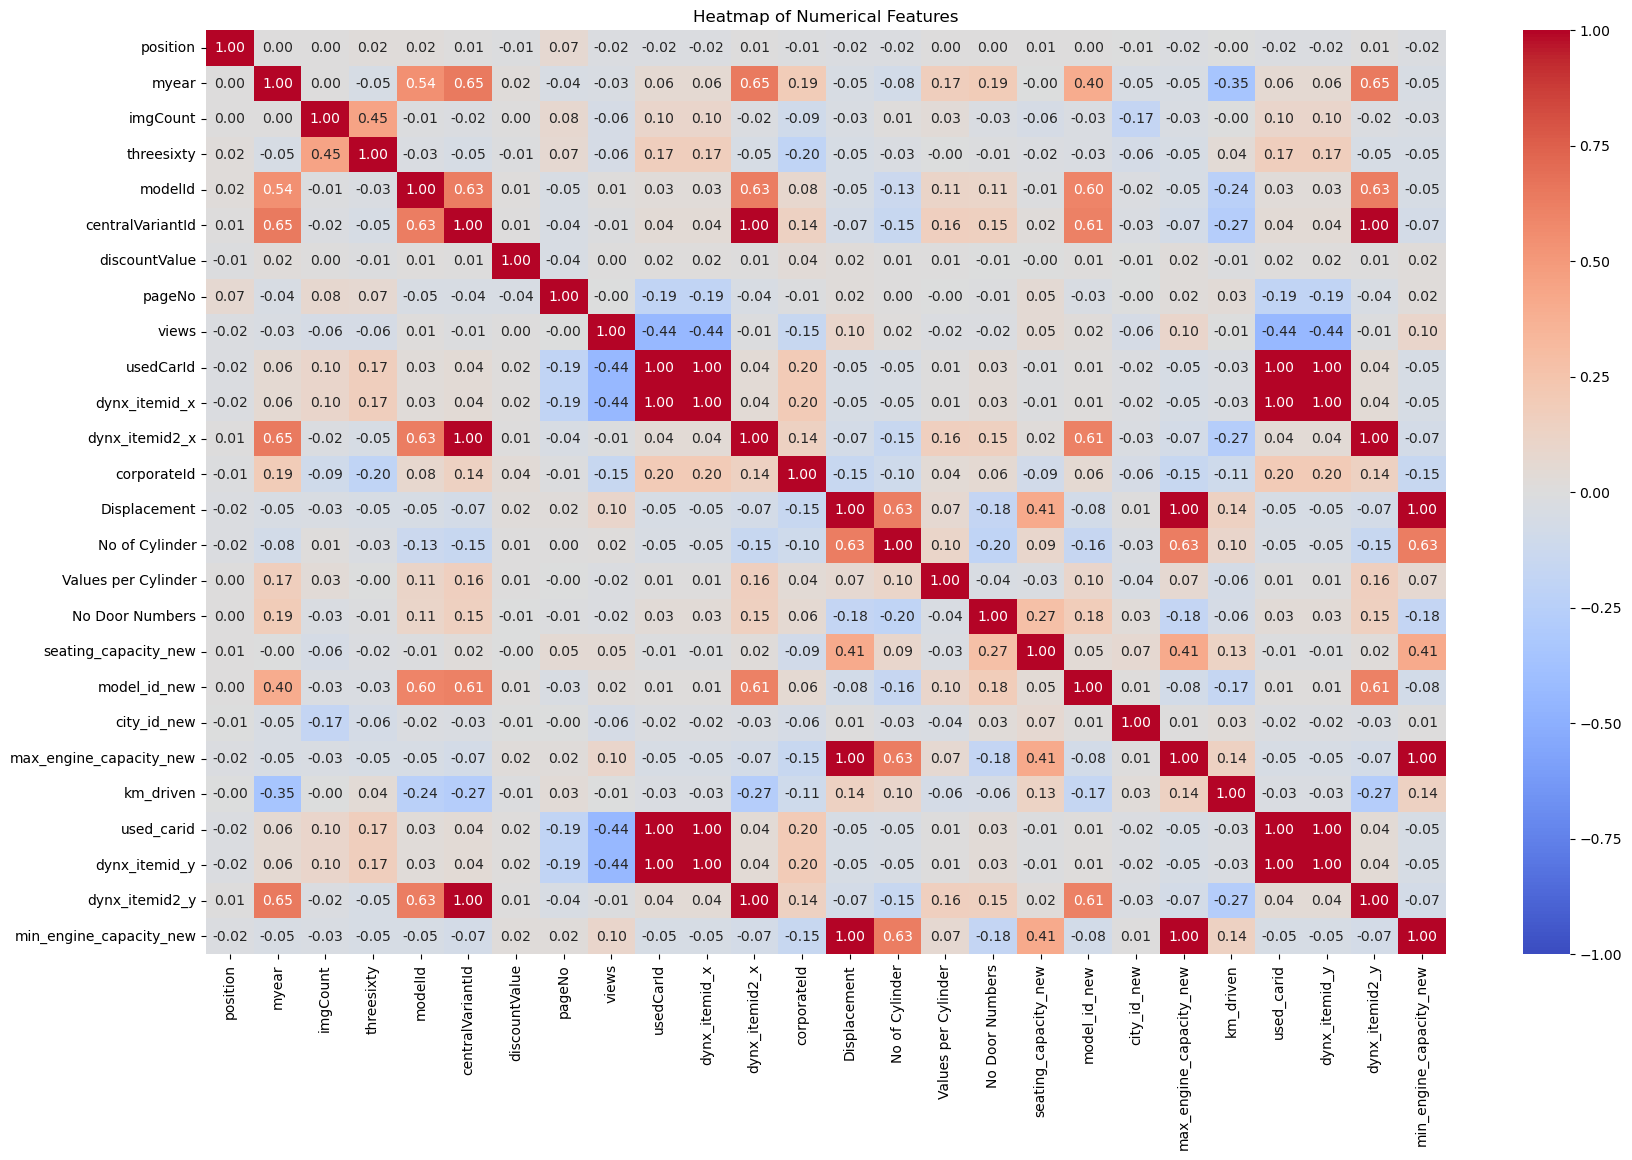

In [11]:
# Compute the correlation matrix
corr_matrix = numerical_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap of Numerical Features")
plt.show()

Numerical Columns:
['position', 'myear', 'imgCount', 'modelId', 'centralVariantId', 'discountValue', 'pageNo', 'views', 'usedCarId', 'dynx_itemid_x', 'dynx_itemid2_x', 'corporateId', 'Displacement', 'No of Cylinder', 'Values per Cylinder', 'No Door Numbers', 'seating_capacity_new', 'model_id_new', 'city_id_new', 'max_engine_capacity_new', 'km_driven', 'used_carid', 'dynx_itemid_y', 'dynx_itemid2_y', 'min_engine_capacity_new']


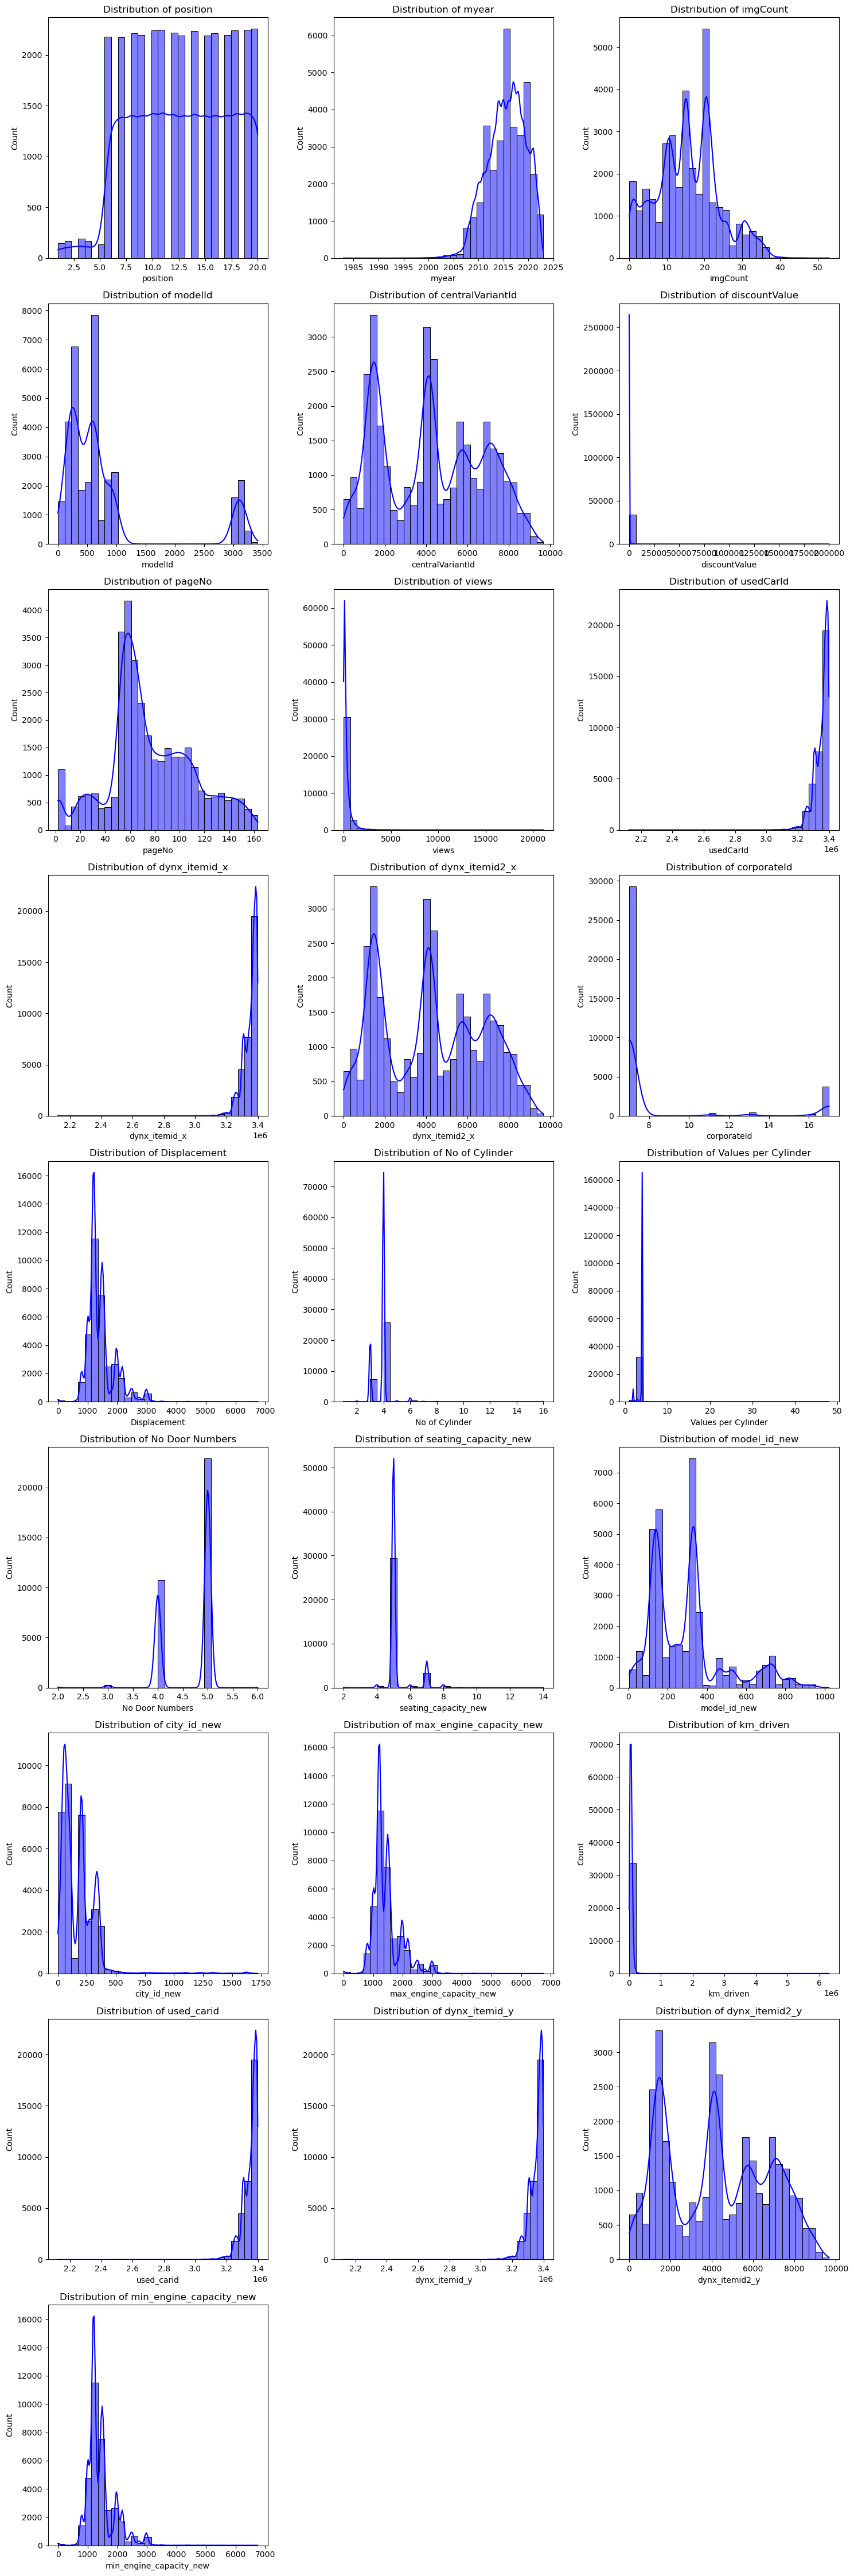

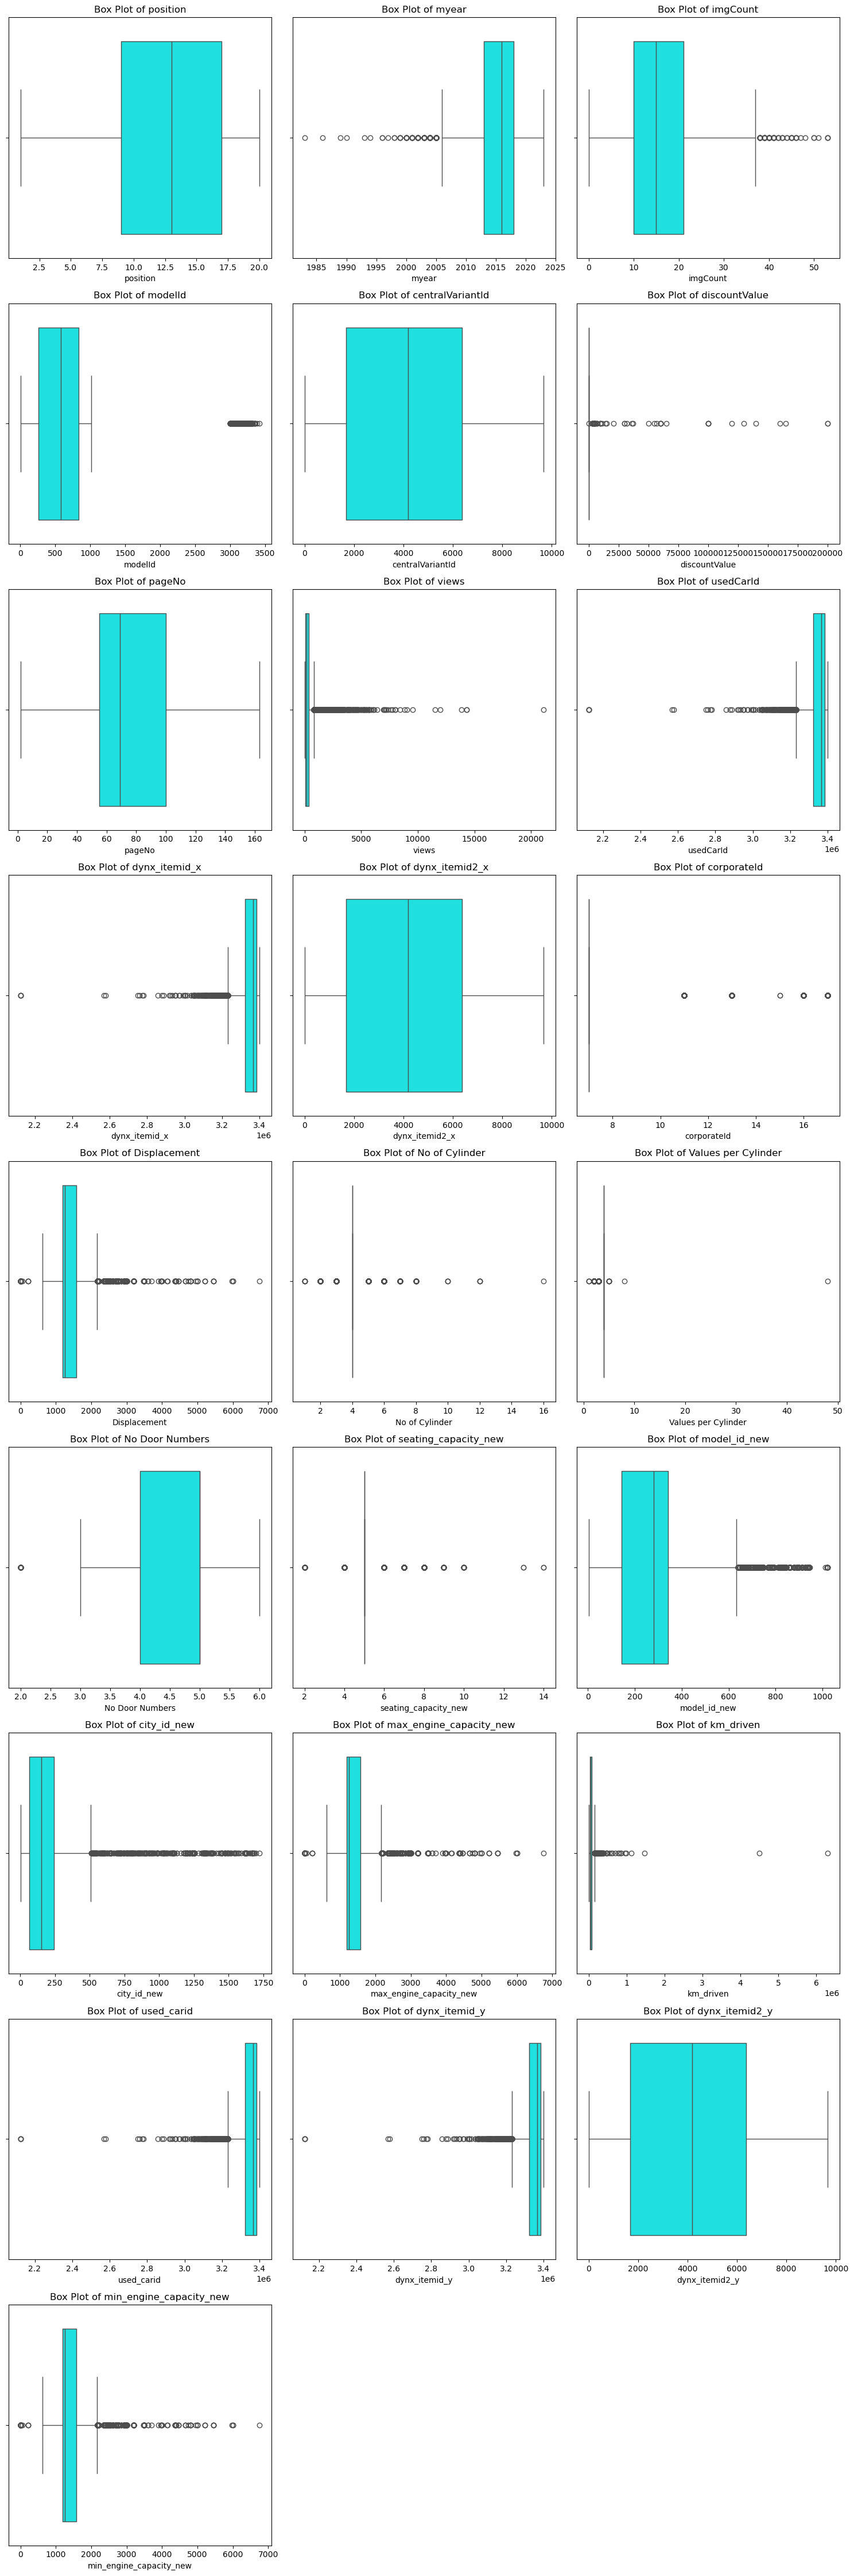

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = data.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

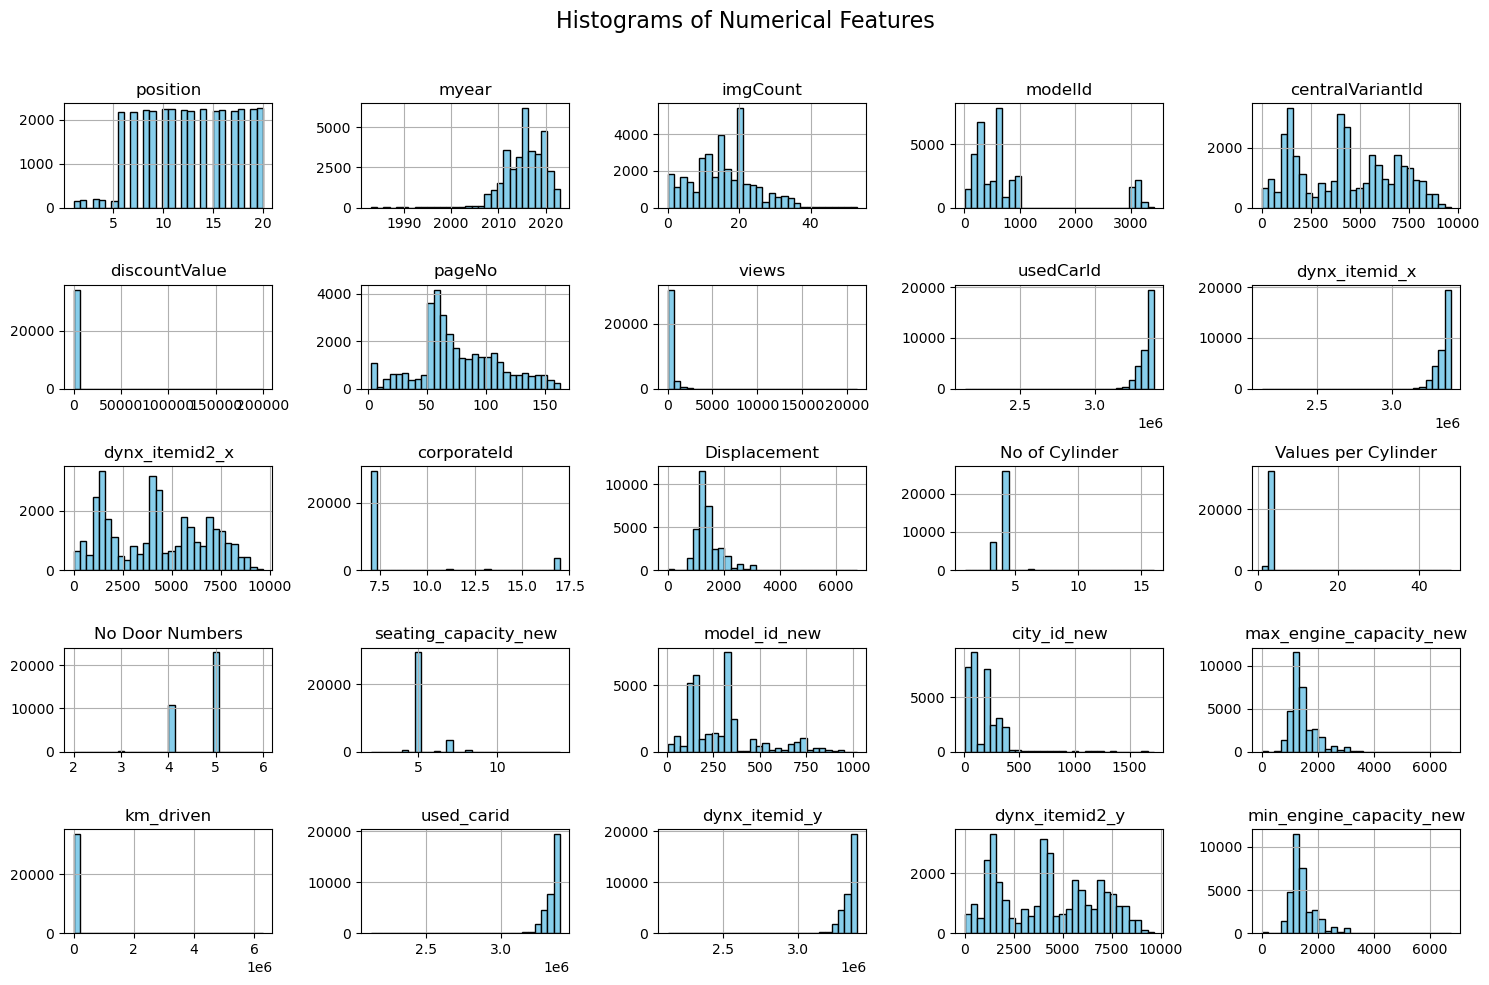

In [13]:
# Plot histograms for all numerical columns
numerical_data.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

For columns position, coperateId, imgCount, used_carid and discountValue they dont add any meaning while predicting car transimmision, as you cant extract from them will a car have a manual or automatic, so will drop them



In [14]:
# List of columns to drop
cols_to_drop = [
    "position", "omperateId", "imgCount", "discountValue", "used_carid"
]

for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(columns=[col])



Data Preprocessing:

In [15]:

# Step 1: Fix formatting issues
# Price (`pu`)
data['pu'] = data['pu'].str.replace(',', '').astype(float)

# Max Power
data['Max Power'] = data['Max Power'].str.extract(r'(\d+\.?\d*)bhp').astype(float)

# Max Torque
data['Max Torque'] = data['Max Torque'].str.extract(r'(\d+\.?\d*)Nm').astype(float)

# Top Speed
data['Top Speed'] = data['Top Speed'].str.extract(r'(\d+\.?\d*)').astype(float)

# Acceleration
data['Acceleration'] = data['Acceleration'].str.extract(r'(\d+\.?\d*)').astype(float)

# Mileage (`mileage_new`)
data['mileage_new'] = data['mileage_new'].str.extract(r'(\d+\.?\d*)').astype(float)

data["car_age"] = 2025 - data["myear"]


In [16]:
# Turbo Charger and Super Charger
data['Turbo Charger'] = data['Turbo Charger'].str.lower().map({'yes': 1, 'no': 0})
data['Super Charger'] = data['Super Charger'].str.lower().map({'yes': 1, 'no': 0})

# One-hot encode 'carType' and drop the original column
if "ft" in data.columns:
    data = pd.get_dummies(data, columns=["ft"], prefix="ft")


In [17]:
# Clean the Gear Number column
def clean_gear_number(gear):
    if pd.isna(gear):  # Handle missing values
        return np.nan
    gear = gear.strip().lower()  # Normalize case and remove extra spaces
    if 'cvt' in gear:  # Handle CVT as null
        return np.nan
    # Extract the numeric part using regex
    numeric_part = ''.join(filter(str.isdigit, gear))
    return numeric_part if numeric_part else np.nan  # Return NaN if no number is found

# Apply the cleaning function
data['Gear Box'] = data['Gear Box'].apply(clean_gear_number)

# Print the cleaned column
print(data["Gear Box"])

0        5
1        6
2        5
3        6
4        5
        ..
34028    7
34029    5
34030    5
34031    5
34032    5
Name: Gear Box, Length: 34033, dtype: object


In [18]:
# Enhanced loop to show unique values, their counts, null counts, null percentage, and categorize columns
numerical_cols = []
categorical_cols = []

for col in data.columns:
    unique_vals = data[col].unique()
    num_null = data[col].isnull().sum()
    pct_null = 100 * num_null / len(data)
    dtype = data[col].dtype

    print(f"Column: {col}")
    print(f"  Unique values: {unique_vals[:10]}{' ...' if len(unique_vals) > 10 else ''}")
    print(f"  Number of unique values: {len(unique_vals)}")
    print(f"  Value counts (top 5):")
    print(data[col].value_counts(dropna=False).head())
    print(f"  Null values: {num_null} ({pct_null:.2f}%)")
    print(f"  Dtype: {dtype}")

    if pd.api.types.is_numeric_dtype(data[col]):
        numerical_cols.append(col)
        print("  Category: Numerical")
    else:
        categorical_cols.append(col)
        print("  Category: Categorical")
    print("-" * 40)

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"Total categorical columns: {len(categorical_cols)}")

Column: myear
  Unique values: [2016 2014 2020 2018 2017 2011 2019 2013 2015 2012] ...
  Number of unique values: 34
  Value counts (top 5):
myear
2017    3534
2018    3310
2014    3171
2015    3116
2016    3057
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: int64
  Category: Numerical
----------------------------------------
Column: bt
  Unique values: ['MUV' 'SUV' 'Hatchback' 'Sedan' 'Minivans' 'Coupe' 'Luxury Vehicles'
 'Convertibles' 'Pickup Trucks' nan] ...
  Number of unique values: 12
  Value counts (top 5):
bt
Hatchback    13580
Sedan         9467
SUV           8831
MUV           1628
Minivans       350
Name: count, dtype: int64
  Null values: 18 (0.05%)
  Dtype: object
  Category: Categorical
----------------------------------------
Column: tt
  Unique values: ['Manual' 'Automatic']
  Number of unique values: 2
  Value counts (top 5):
tt
Manual       26034
Automatic     7999
Name: count, dtype: int64
  Null values: 0 (0.00%)
  Dtype: object
  Category: Categorical

In [19]:

# Step 4: Balance the dataset
# Define features to use
#, 'ft_CNG', 'ft_Diesel', 'ft_Electric', 'ft_LPG', 'ft_Petrol'
features = ["pu", "Max Power", "Max Torque", "Top Speed", "Acceleration", "mileage_new", "Turbo Charger",
             "Super Charger", "km_driven", 'car_age' , 'ft_CNG',
               'ft_Diesel', 'ft_Electric', 'ft_LPG', 'ft_Petrol', "Gear Box"]
X = data[features]
y = data['tt']
# Encode target variable (`tt`)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


Numerical Columns:
['pu', 'Max Power', 'Max Torque', 'Top Speed', 'Acceleration', 'mileage_new', 'Turbo Charger', 'Super Charger', 'km_driven', 'car_age']


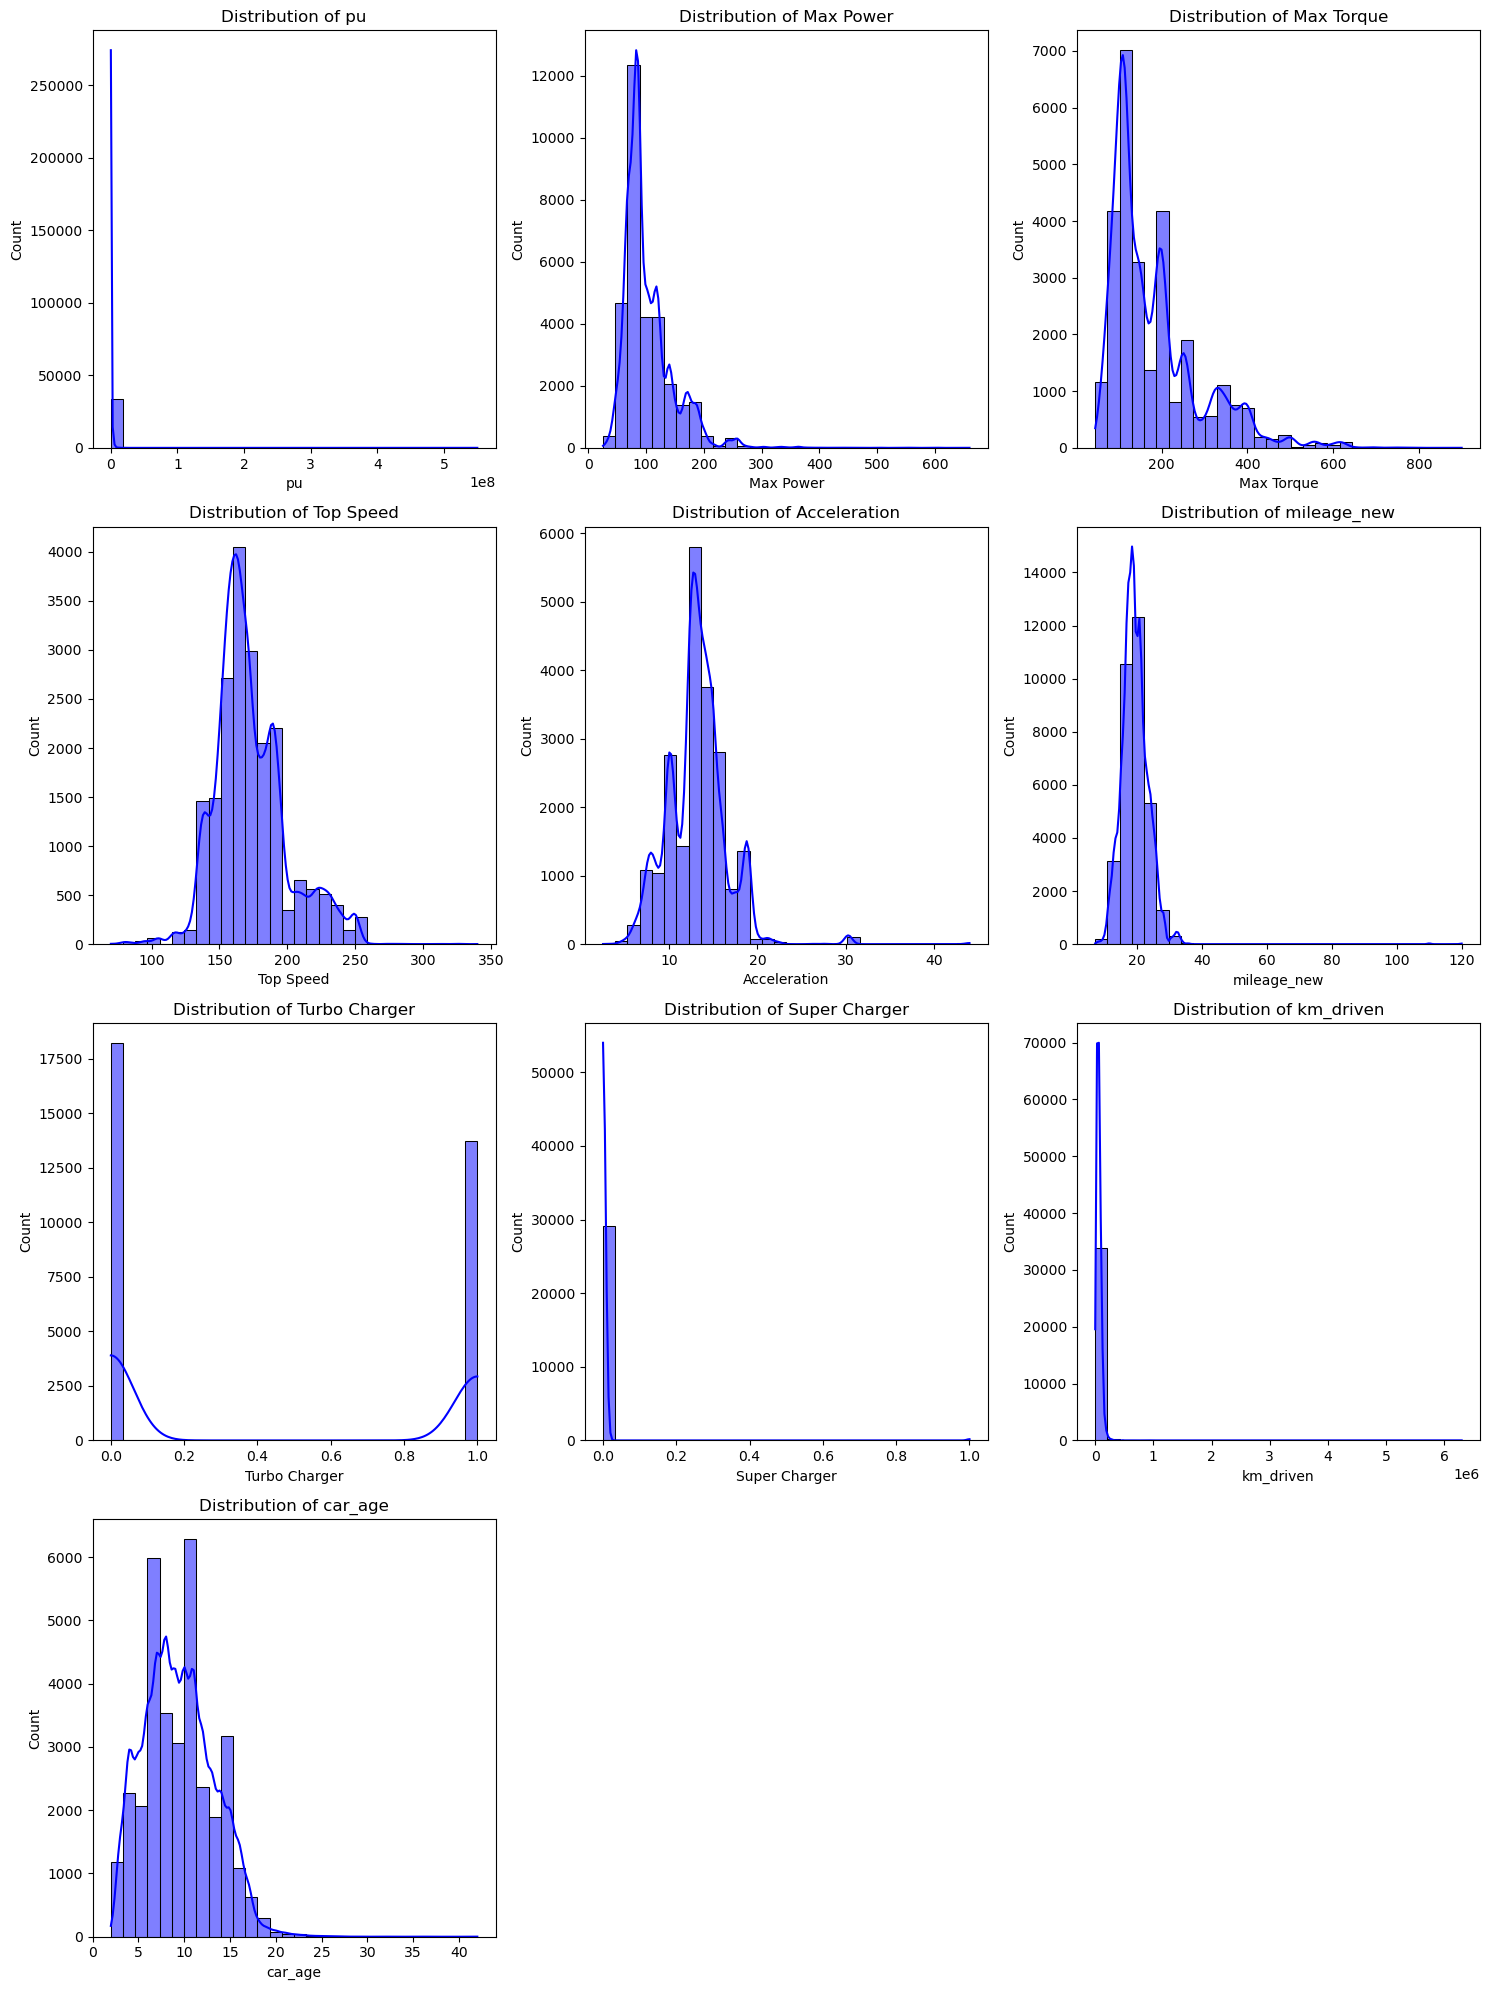

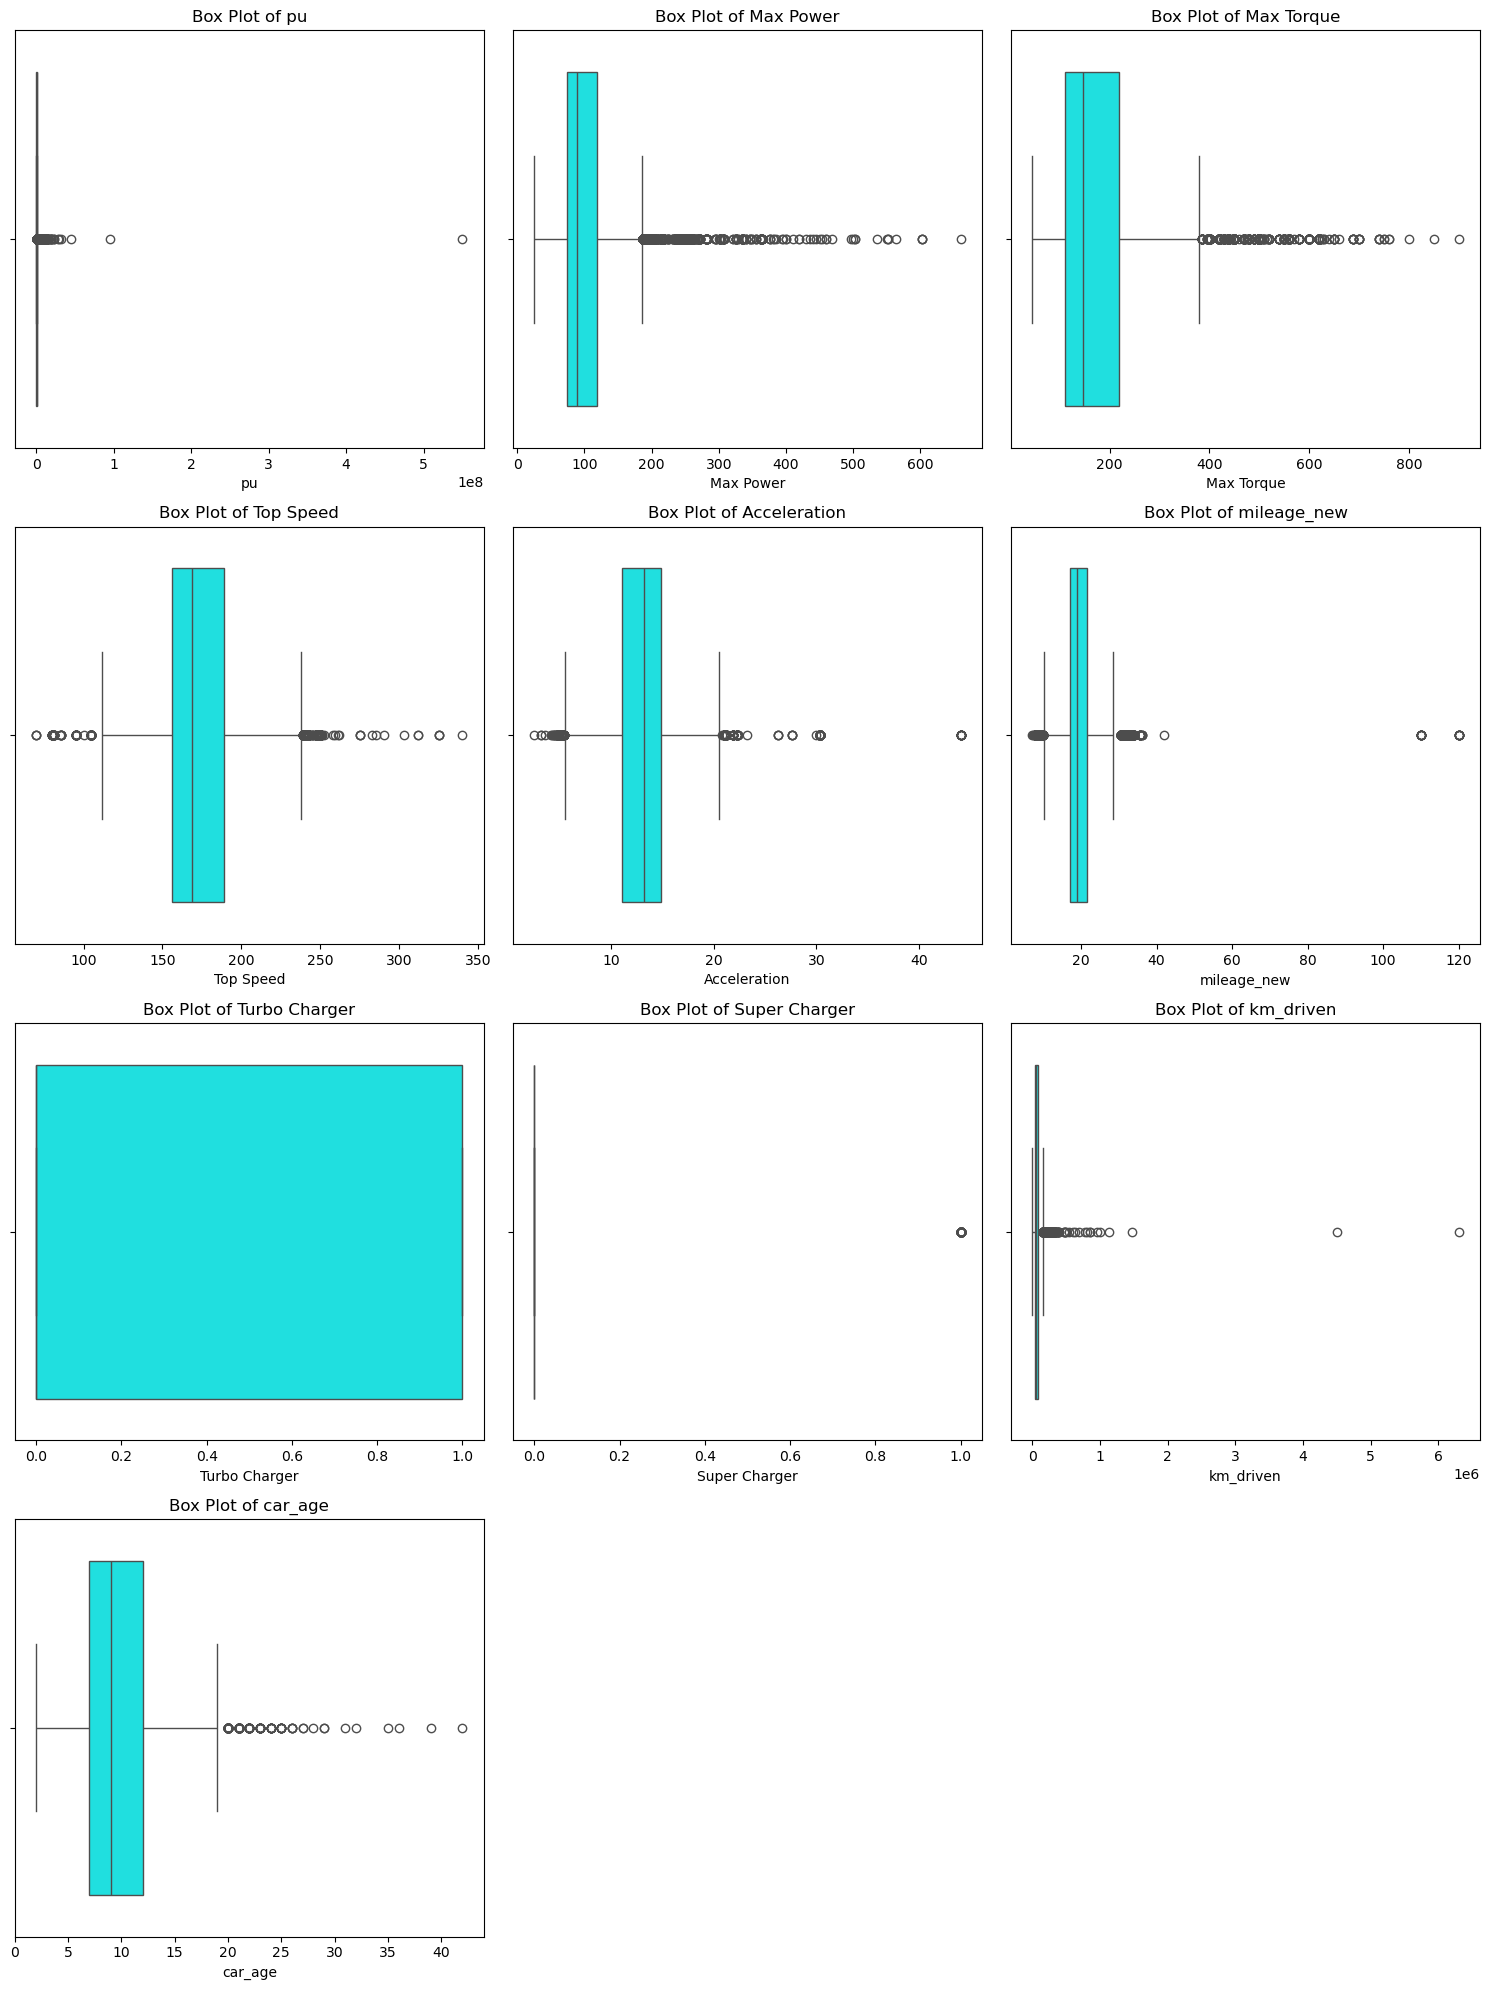

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = X.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [21]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import StandardScaler


In [22]:
X_train.shape[0], X_val.shape[0], y_train.shape[0], y_val.shape[0]  # Check the shapes of the splits

(27226, 6807, 27226, 6807)

In [23]:
# --- Apply Log Transform to `pu` ---
# Ensure no negative values (add 1 to handle zeros if needed)
X_train["pu"] = np.log1p(X_train["pu"])  # log(1 + x) for stability
X_val["pu"] = np.log1p(X_val["pu"])

In [24]:
# Calculate IQR bounds on TRAINING data
'''Q1 = X_train.quantile(0.15)
Q3 = X_train.quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip outliers in TRAINING and VALIDATION data
X_train_clipped = X_train.clip(lower_bound, upper_bound, axis=1)
X_val_clipped = X_val.clip(lower_bound, upper_bound, axis=1)
'''
# Select only numeric columns for outlier handling
numerical_cols = X_train.select_dtypes(include=['float64', 'int64', 'int32', 'float32']).columns

# Calculate IQR bounds on TRAINING data (only for numeric columns)
Q1 = X_train[numerical_cols].quantile(0.15)
Q3 = X_train[numerical_cols].quantile(0.90)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip outliers in TRAINING and VALIDATION data (only for numeric columns)
X_train_clipped = X_train.copy()
X_val_clipped = X_val.copy()

X_train_clipped[numerical_cols] = X_train[numerical_cols].clip(lower_bound, upper_bound, axis=1)
X_val_clipped[numerical_cols] = X_val[numerical_cols].clip(lower_bound, upper_bound, axis=1)

# Ensure one-hot encoded features are preserved
non_numeric_cols = X_train.select_dtypes(exclude=['float64', 'int64', 'int32', 'float32']).columns
X_train_clipped[non_numeric_cols] = X_train[non_numeric_cols]
X_val_clipped[non_numeric_cols] = X_val[non_numeric_cols]

# Now X_train_clipped and X_val_clipped include both clipped numeric features and one-hot encoded features

Numerical Columns:
['pu', 'Max Power', 'Max Torque', 'Top Speed', 'Acceleration', 'mileage_new', 'Turbo Charger', 'Super Charger', 'km_driven', 'car_age']


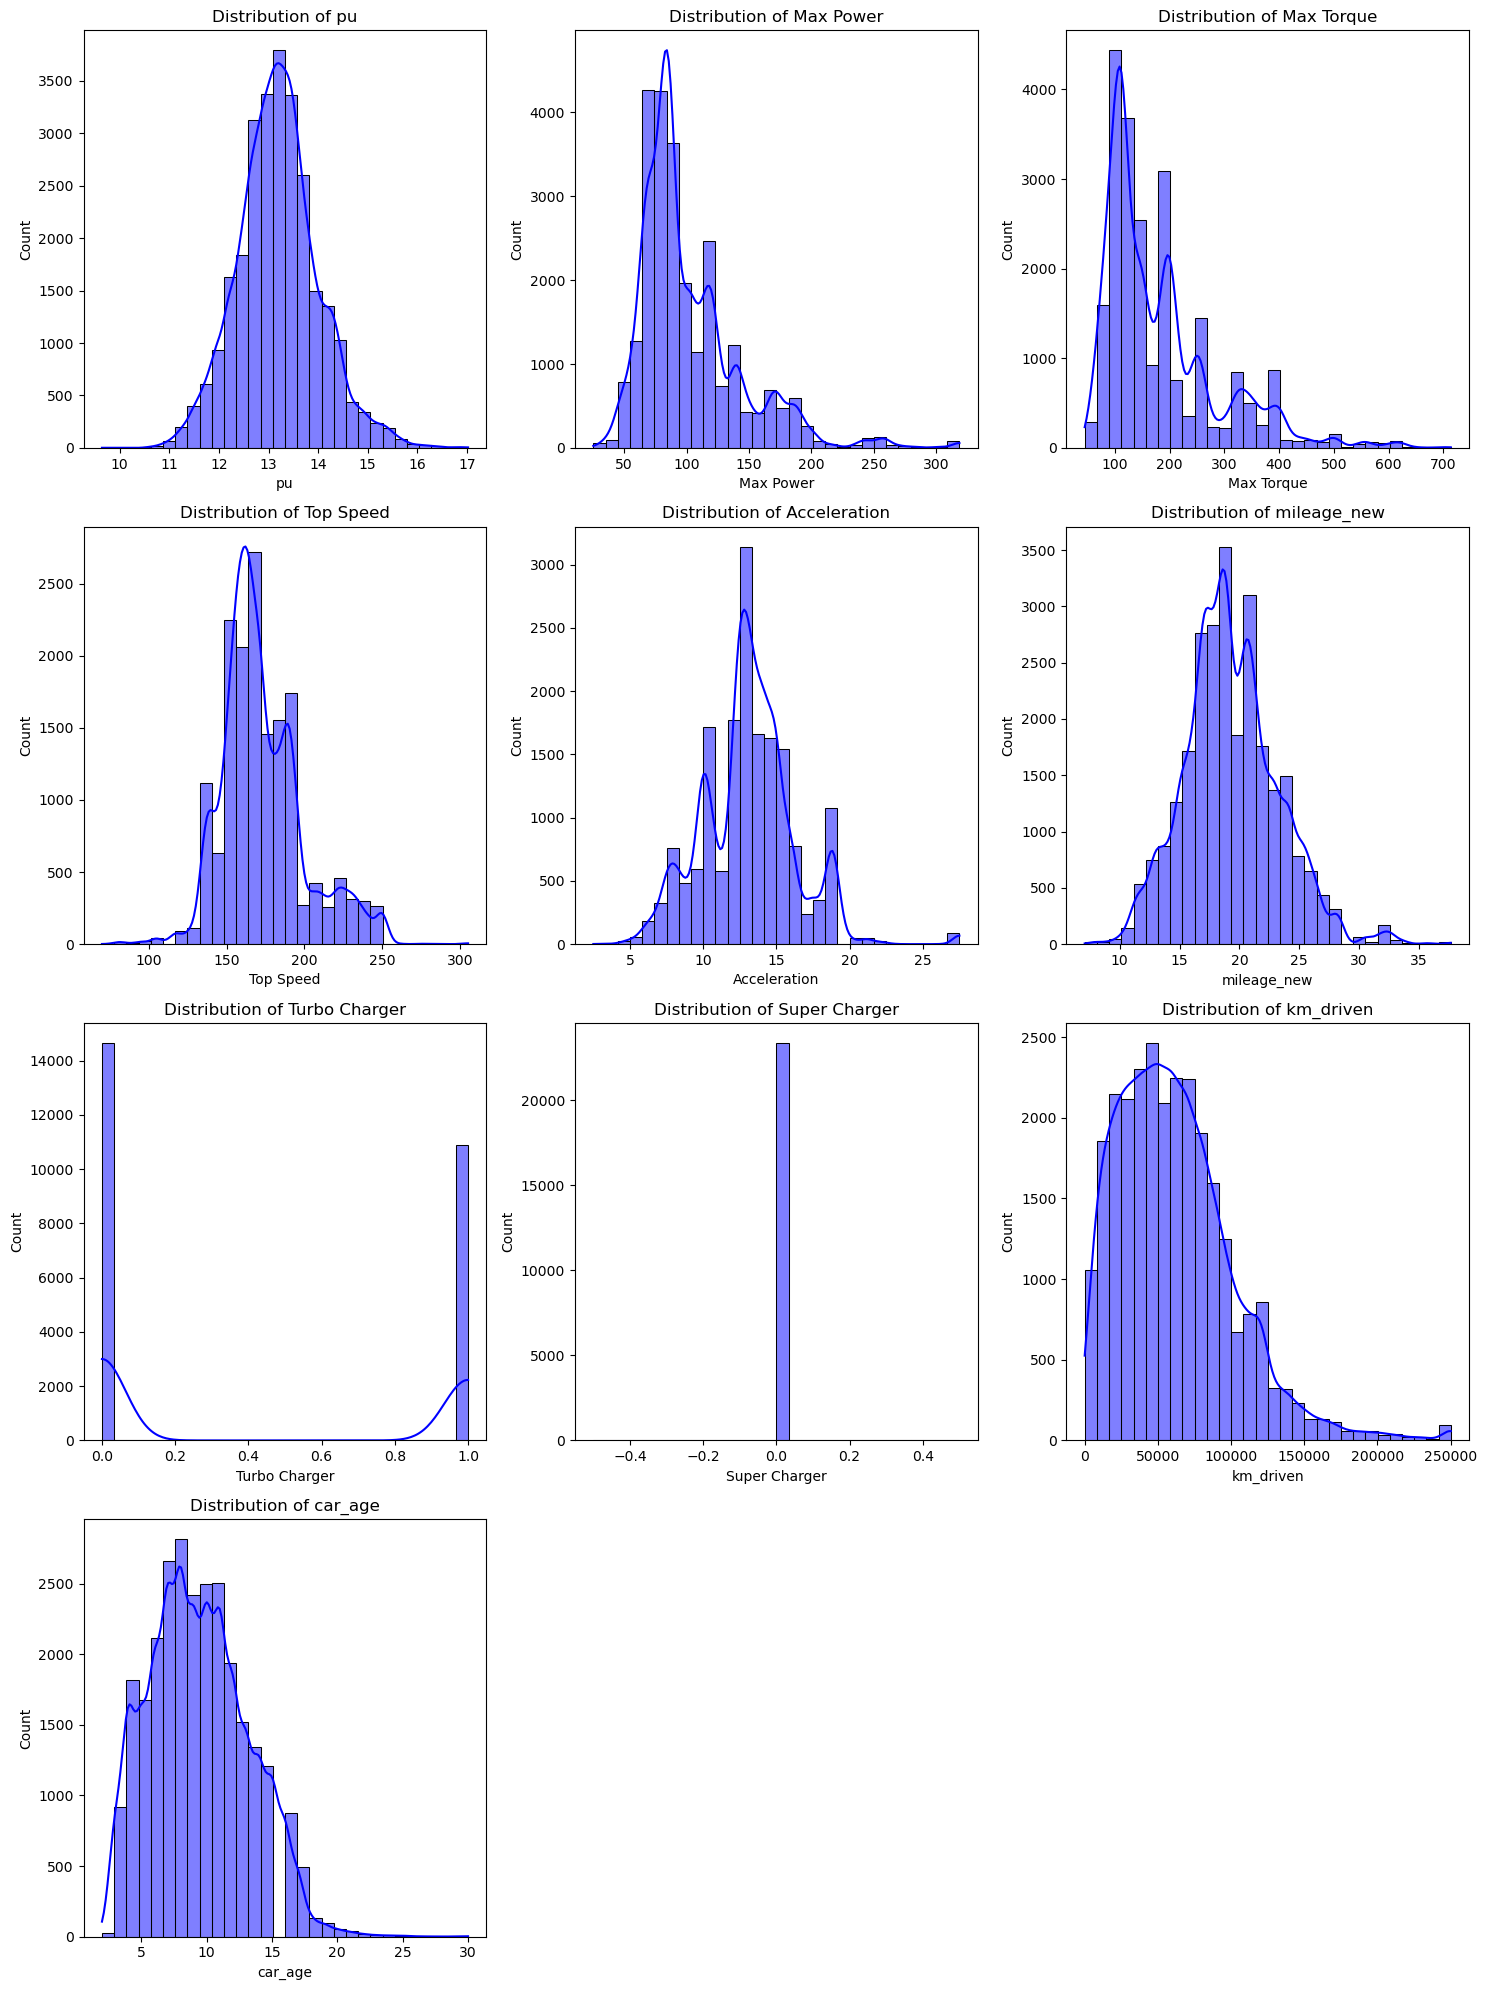

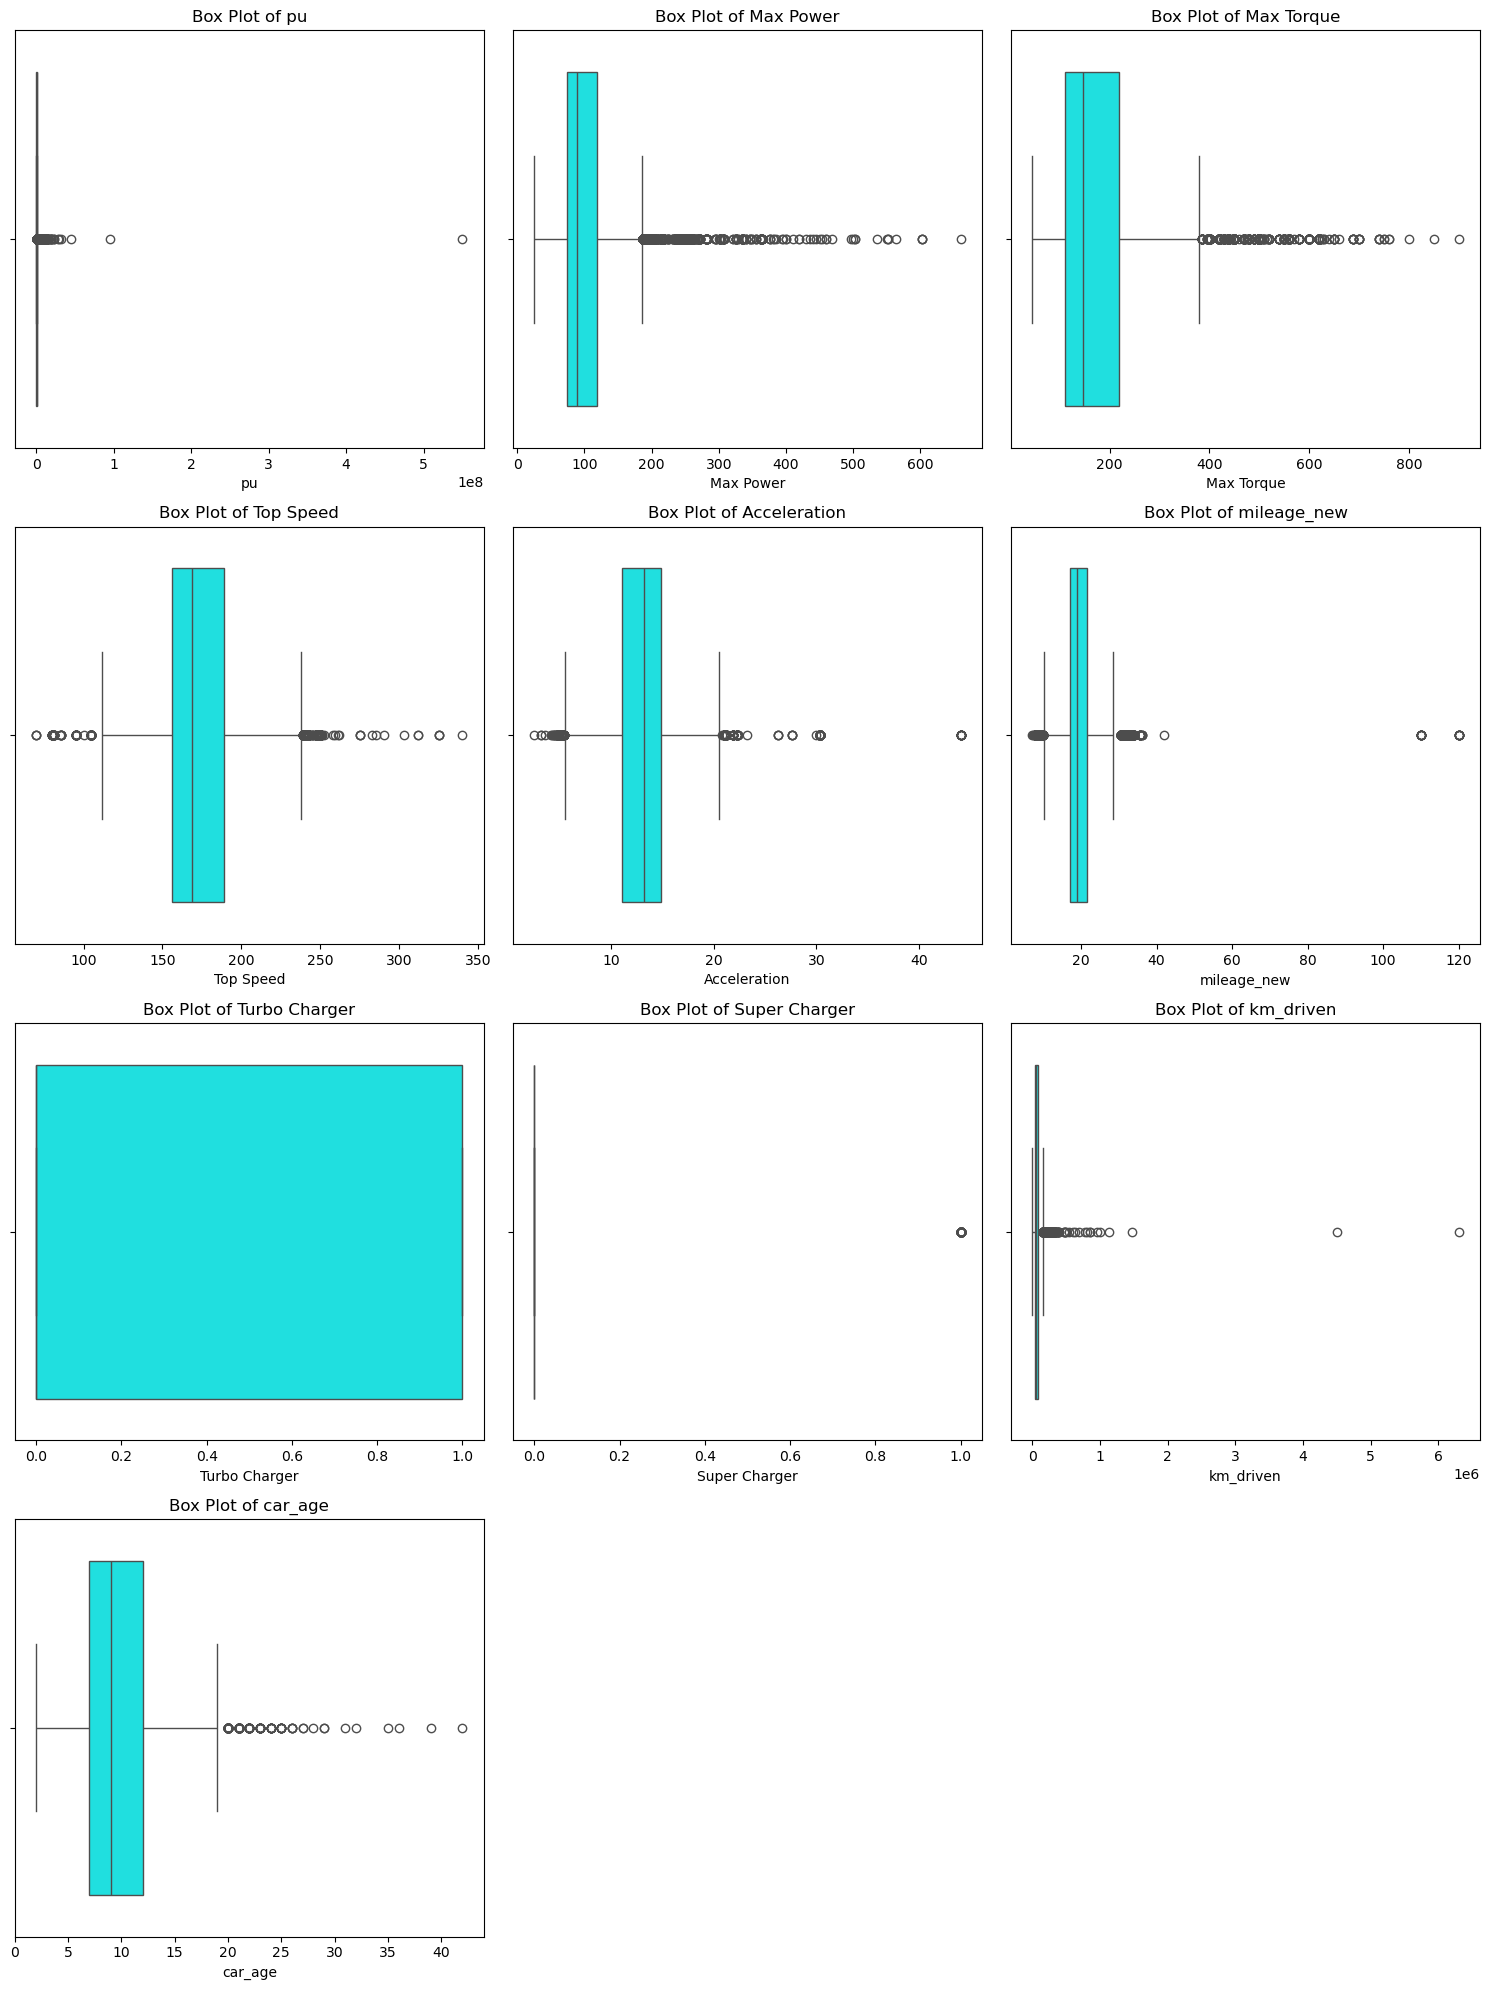

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (excluding boolean columns)
# Use select_dtypes to filter numeric columns (int, float) and exclude bool
numerical_data = X_train_clipped.select_dtypes(include=['float64', 'int64', 'int32', 'float32'])

# Print the numerical columns
print("Numerical Columns:")
print(numerical_data.columns.tolist())

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_data.columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X_train_clipped[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# --- BOX PLOTS ---
plt.figure(figsize=(15, 5 * n_rows))  # Adjust height dynamically
for i, feature in enumerate(numerical_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [26]:


# Scale features (fit on training, transform both sets)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clipped)
X_val_scaled = scaler.transform(X_val_clipped)


In [27]:


# Impute missing values (fit on training, transform both sets)
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_val_imputed = imputer.transform(X_val_scaled)



In [28]:

# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imputed, y_train)


In [29]:
X_train_res.shape[0]

41638

In [30]:
import pickle
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file) # To save the variable into the `scaler.pkl` file.

Selecting and hyper tuning/ finetuning Machines learning model and conducting performance analysis: 

In [31]:

# Step 6: Build the neural network
model = Sequential([
    Dense(64, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5581 - loss: 0.7245 - val_accuracy: 0.2365 - val_loss: 0.7919
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6116 - loss: 0.6715 - val_accuracy: 0.2362 - val_loss: 0.7865
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6518 - loss: 0.6286 - val_accuracy: 0.2367 - val_loss: 0.7811
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6833 - loss: 0.5945 - val_accuracy: 0.2403 - val_loss: 0.7757
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7074 - loss: 0.5673 - val_accuracy: 0.2445 - val_loss: 0.7705
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7221 - loss: 0.5452 - val_accuracy: 0.2514 - val_loss: 0.7655
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7323 - loss: 0.5267 - val_accuracy: 0.2611 - val_loss: 0.7606
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7394 - loss: 0.5109 - val_accuracy: 0.275

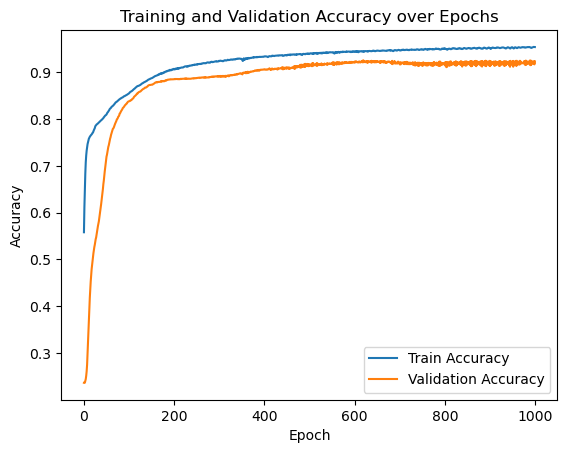

In [32]:
# Train the model with full-batch gradient descent (no mini-batches)
history = model.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on validation set
y_pred_prob = model.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9230
Precision: 0.9655
Recall: 0.9329


In [34]:
from tensorflow.keras.layers import Dense, Dropout
# Model 2 
model2 = Sequential([
    Dense(64, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Train the model with full-batch gradient descent (no mini-batches)
history2 = model2.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model2.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4251 - loss: 0.9319 - val_accuracy: 0.2339 - val_loss: 1.0306
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.4625 - loss: 0.8691 - val_accuracy: 0.2339 - val_loss: 1.0082
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4933 - loss: 0.8235 - val_accuracy: 0.2339 - val_loss: 0.9861
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5251 - loss: 0.7770 - val_accuracy: 0.2339 - val_loss: 0.9645
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5601 - loss: 0.7368 - val_accuracy: 0.2339 - val_loss: 0.9436
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5877 - loss: 0.7017 - val_accuracy: 0.2339 - val_loss: 0.9236
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6156 - loss: 0.6707 - val_accuracy: 0.2339 - val_loss: 0.9046
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6374 - loss: 0.6430 - val_accuracy: 0.233

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9251
Precision: 0.9530
Recall: 0.9490


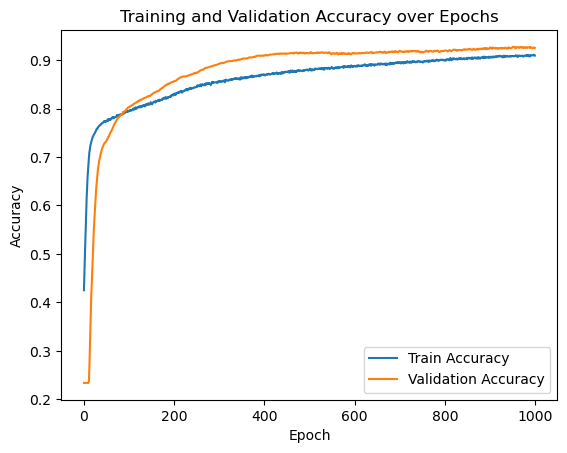

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on validation set
y_pred_prob = model2.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [37]:
from tensorflow.keras.layers import Dense, Dropout
# Model 3
model3 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
# Train the model with full-batch gradient descent (no mini-batches)
history3 = model3.fit(
    X_train_res, y_train_res,
    epochs=1200,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model3.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

Epoch 1/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5287 - loss: 0.8060 - val_accuracy: 0.7636 - val_loss: 0.6335
Epoch 2/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.6173 - loss: 0.6907 - val_accuracy: 0.8005 - val_loss: 0.6207
Epoch 3/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6801 - loss: 0.6089 - val_accuracy: 0.8105 - val_loss: 0.6098
Epoch 4/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7181 - loss: 0.5600 - val_accuracy: 0.8142 - val_loss: 0.6005
Epoch 5/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.7357 - loss: 0.5243 - val_accuracy: 0.8123 - val_loss: 0.5924
Epoch 6/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.7469 - loss: 0.5043 - val_accuracy: 0.8120 - val_loss: 0.5854
Epoch 7/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7546 - loss: 0.4876 - val_accuracy: 0.8109 - val_loss: 0.5792
Epoch 8/1200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7586 - loss: 0.4749 - val_accuracy: 0.810

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on validation set
y_pred_prob = model3.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9304
Precision: 0.9759
Recall: 0.9321


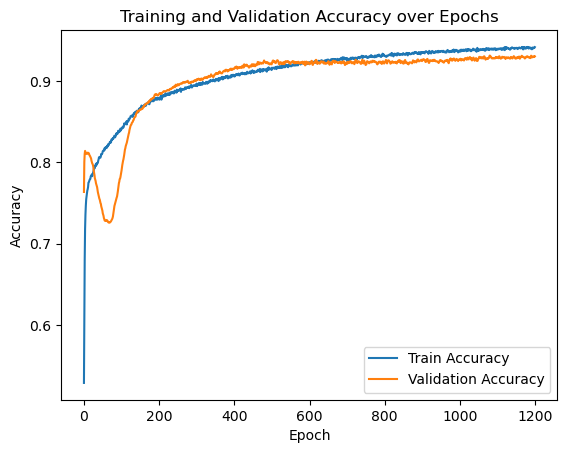

In [40]:
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [41]:
from tensorflow.keras.layers import Dense, Dropout
# Model 4 
model4 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])

model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4331 - loss: 0.8702 - val_accuracy: 0.7625 - val_loss: 0.6570
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.4677 - loss: 0.8082 - val_accuracy: 0.7620 - val_loss: 0.6539
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5079 - loss: 0.7555 - val_accuracy: 0.7594 - val_loss: 0.6516
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5538 - loss: 0.7084 - val_accuracy: 0.7608 - val_loss: 0.6502
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.5934 - loss: 0.6751 - val_accuracy: 0.7735 - val_loss: 0.6494
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6313 - loss: 0.6452 - val_accuracy: 0.7964 - val_loss: 0.6486
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.6607 - loss: 0.6160 - val_accuracy: 0.7920 - val_loss: 0.6474
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6858 - loss: 0.5932 - val_accuracy: 0.782

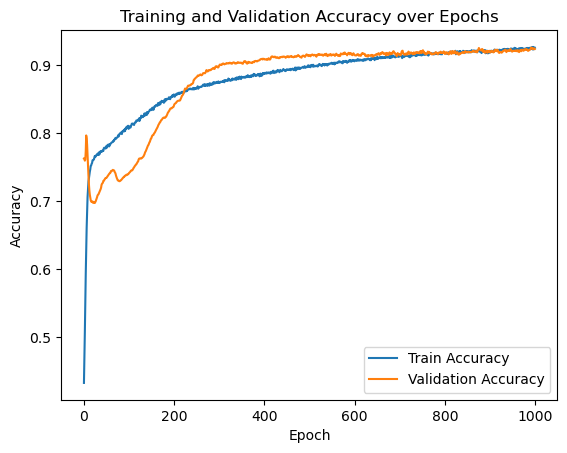

In [42]:
# Train the model with full-batch gradient descent (no mini-batches)
history4 = model4.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model4.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [43]:
from tensorflow.keras.layers import Dense, Dropout
# Model 5
model5 = Sequential([
    Dense(32, input_dim=X_train_res.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')  # Binary classification
])

model5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5214 - loss: 0.6777 - val_accuracy: 0.2596 - val_loss: 0.7970
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5252 - loss: 0.6698 - val_accuracy: 0.2746 - val_loss: 0.7835
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5348 - loss: 0.6606 - val_accuracy: 0.2894 - val_loss: 0.7705
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5390 - loss: 0.6546 - val_accuracy: 0.3051 - val_loss: 0.7579
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5447 - loss: 0.6474 - val_accuracy: 0.3264 - val_loss: 0.7457
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5538 - loss: 0.6399 - val_accuracy: 0.3499 - val_loss: 0.7341
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5651 - loss: 0.6320 - val_accuracy: 0.3739 - val_loss: 0.7229
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5746 - loss: 0.6266 - val_accuracy: 0.4080 - val

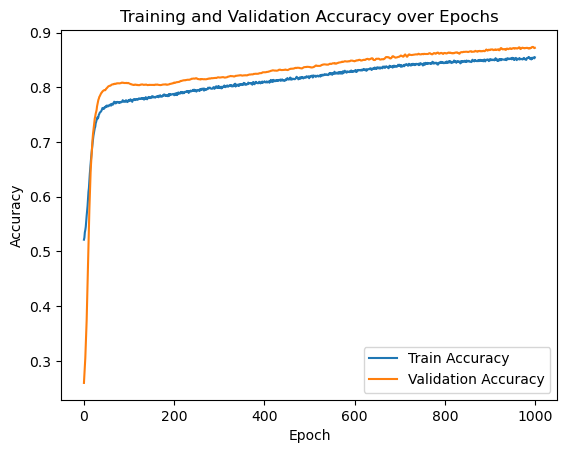

In [44]:
# Train the model with full-batch gradient descent (no mini-batches)
history5 = model5.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model5.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history5.history['accuracy'], label='Train Accuracy')
plt.plot(history5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [45]:
from tensorflow.keras.layers import Dense, Dropout
# Model 6
model6 = Sequential([
    Dense(128, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

model6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4119 - loss: 1.0246 - val_accuracy: 0.7304 - val_loss: 0.6677
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.4575 - loss: 0.9151 - val_accuracy: 0.7929 - val_loss: 0.6539
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.5216 - loss: 0.8126 - val_accuracy: 0.7981 - val_loss: 0.6423
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5812 - loss: 0.7308 - val_accuracy: 0.8001 - val_loss: 0.6324
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6283 - loss: 0.6776 - val_accuracy: 0.8017 - val_loss: 0.6243
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.6637 - loss: 0.6322 - val_accuracy: 0.7893 - val_loss: 0.6180
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.6857 - loss: 0.6009 - val_accuracy: 0.7779 - val_loss: 0.6132
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7093 - loss: 0.5715 - val_accuracy: 0.764

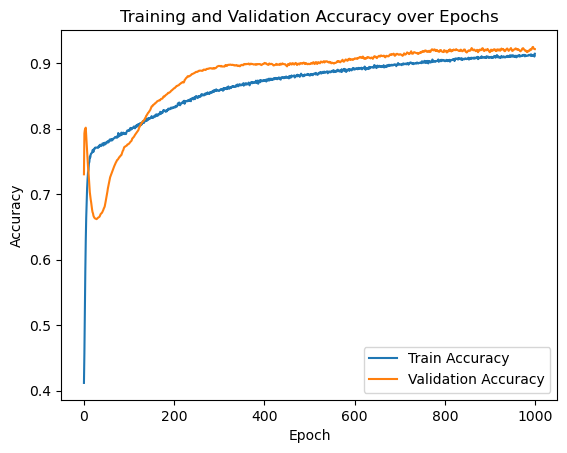

In [46]:
# Train the model with full-batch gradient descent (no mini-batches)
history6 = model6.fit(
    X_train_res, y_train_res,
    epochs=1000,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model6.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history6.history['accuracy'], label='Train Accuracy')
plt.plot(history6.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on validation set
y_pred_prob = model6.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9216
Precision: 0.9697
Recall: 0.9266


In [48]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
# Model 7
model7 = Sequential([
    Dense(512, input_dim=X_train_res.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(64, activation='relu'),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),   
    Dropout(0.1),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')  # Binary classification
])

model7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step - accuracy: 0.9574 - loss: 0.1313 - val_accuracy: 0.9373 - val_loss: 0.1911
Epoch 2/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step - accuracy: 0.9562 - loss: 0.1326 - val_accuracy: 0.9362 - val_loss: 0.1910
Epoch 3/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step - accuracy: 0.9563 - loss: 0.1321 - val_accuracy: 0.9339 - val_loss: 0.1939
Epoch 4/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step - accuracy: 0.9567 - loss: 0.1336 - val_accuracy: 0.9326 - val_loss: 0.1938
Epoch 5/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step - accuracy: 0.9574 - loss: 0.1311 - val_accuracy: 0.9333 - val_loss: 0.1917
Epoch 6/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step - accuracy: 0.9563 - loss: 0.1336 - val_accuracy: 0.9380 - val_loss: 0.1872
Epoch 7/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step - accuracy: 0.9557 - loss: 0.1342 - val_accuracy: 0.9348 - val_loss: 0.1913
Epoch 8/670
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step - accuracy: 0.9554 - loss: 0.1325 - val_accuracy: 0.9340 - v

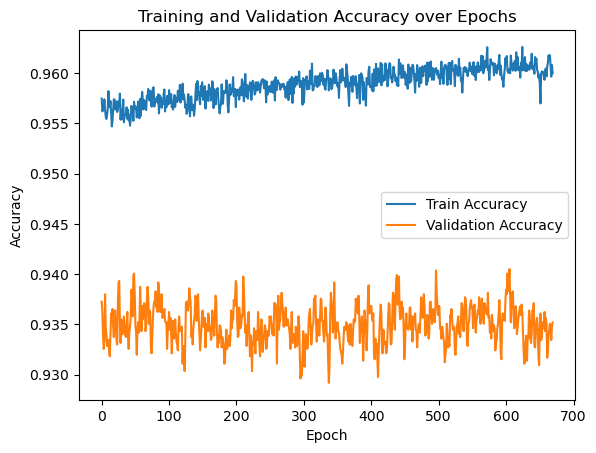

In [51]:
# Train the model with full-batch gradient descent (no mini-batches)
history7 = model7.fit(
    X_train_res, y_train_res,
    epochs=670,
    batch_size=X_train_res.shape[0],  # Use full dataset as a single batch
    validation_data=(X_val_imputed, y_val),
    verbose=1
)

# Evaluate
val_loss, val_accuracy = model7.evaluate(X_val_imputed, y_val, verbose=0)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")
import matplotlib.pyplot as plt

# Plot accuracy and val_accuracy over epochs
plt.plot(history7.history['accuracy'], label='Train Accuracy')
plt.plot(history7.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Predict on validation set
y_pred_prob = model7.predict(X_val_imputed)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.9352
Precision: 0.9776
Recall: 0.9369
